In [11]:
# code here
import cv2
import matplotlib.pyplot as plt
import numpy as np

1) Aplique nas imagens abaixo o algortimo Watershed para realizar a contagem de células. Faça tanto para  a imagem original e para a imagem gradiente

=== RESULTADOS (NA MÃO SIMPLES) PARA: image.jpg ===
Contagem (Imagem Original) : 3354 células/objetos
Contagem (Imagem Gradiente): 3354 células/objetos



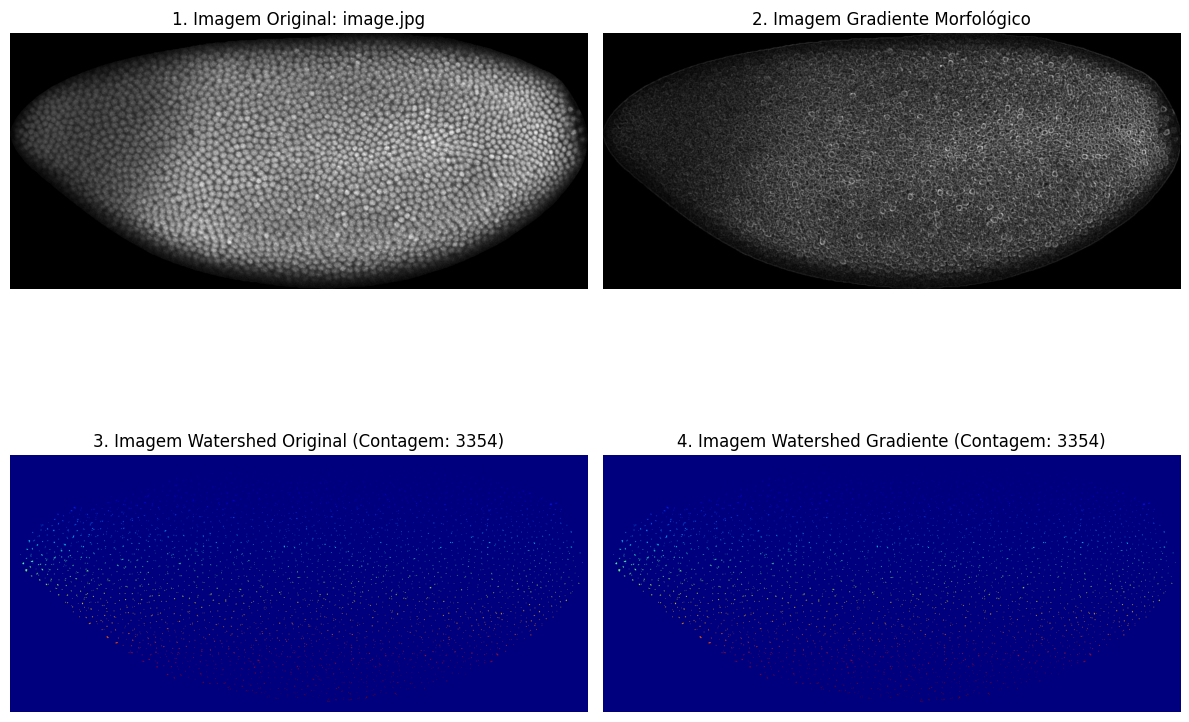

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Algoritmo Watershed Simples
def watershed_simples_na_mao(topo_img, markers):
    labels = markers.copy().astype(np.int32)
    H, W = topo_img.shape
    dr = [-1, 1, 0, 0]
    dc = [0, 0, -1, 1]
    
    mudou = True
    while mudou:
        mudou = False
        novos_labels = labels.copy()
        zeros_r, zeros_c = np.where(labels == 0)
        
        for r, c in zip(zeros_r, zeros_c):
            vizinhos = []
            for i in range(4):
                nr, nc = r + dr[i], c + dc[i]
                if 0 <= nr < H and 0 <= nc < W:
                    if labels[nr, nc] > 0:
                        vizinhos.append(labels[nr, nc])
                        
            if vizinhos:
                unicos = set(vizinhos)
                if len(unicos) == 1:
                    novos_labels[r, c] = list(unicos)[0]
                    mudou = True
                elif len(unicos) > 1:
                    novos_labels[r, c] = -1 # Linha divisora de águas
                    mudou = True
                    
        labels = novos_labels
        
    return labels

def watershed_manual(nome_imagem):
    img_gray = cv2.imread(nome_imagem, cv2.IMREAD_GRAYSCALE)
    if img_gray is None:
        print(f"Erro ao carregar '{nome_imagem}'")
        return

    kernel = np.ones((3, 3), np.uint8)
    blur = cv2.GaussianBlur(img_gray, (5, 5), 0)
    gradient = cv2.morphologyEx(img_gray, cv2.MORPH_GRADIENT, kernel)
    
    local_max = cv2.dilate(blur, np.ones((5, 5), np.uint8))
    peaks = (blur == local_max) & (blur > 30)
    num_labels, markers = cv2.connectedComponents(np.uint8(peaks * 255))
    
    _, thresh_bg = cv2.threshold(blur, 20, 255, cv2.THRESH_BINARY)
    unknown = cv2.bitwise_not(thresh_bg)
    markers = markers + 1
    markers[unknown == 255] = 1 # Fundo
    
    # --- WATERSHED NA MÃO ---
    labels_orig = watershed_simples_na_mao(blur, markers)
    count_orig = len(np.unique(labels_orig[labels_orig > 1]))
    
    labels_grad = watershed_simples_na_mao(gradient, markers)
    count_grad = len(np.unique(labels_grad[labels_grad > 1]))
    
    print(f"=== RESULTADOS (NA MÃO SIMPLES) PARA: {nome_imagem} ===")
    print(f"Contagem (Imagem Original) : {count_orig} células/objetos")
    print(f"Contagem (Imagem Gradiente): {count_grad} células/objetos\n")
    
    # PLOTAGEM (Exibindo a imagem da matriz de rótulos do Watershed com cores)
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    axes[0, 0].imshow(img_gray, cmap='gray')
    axes[0, 0].set_title(f"1. Imagem Original: {nome_imagem}")
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(gradient, cmap='gray')
    axes[0, 1].set_title("2. Imagem Gradiente Morfológico")
    axes[0, 1].axis('off')
    
    # Imagem Watershed na Original
    axes[1, 0].imshow(labels_orig, cmap='jet')
    axes[1, 0].set_title(f"3. Imagem Watershed Original (Contagem: {count_orig})")
    axes[1, 0].axis('off')
    
    # Imagem Watershed no Gradiente
    axes[1, 1].imshow(labels_grad, cmap='jet')
    axes[1, 1].set_title(f"4. Imagem Watershed Gradiente (Contagem: {count_grad})")
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

watershed_manual("image.jpg")

=== RESULTADOS (OpenCV) PARA: image2.jpg ===
Contagem (Imagem Original) : 2377 células/objetos
Contagem (Imagem Gradiente): 2377 células/objetos



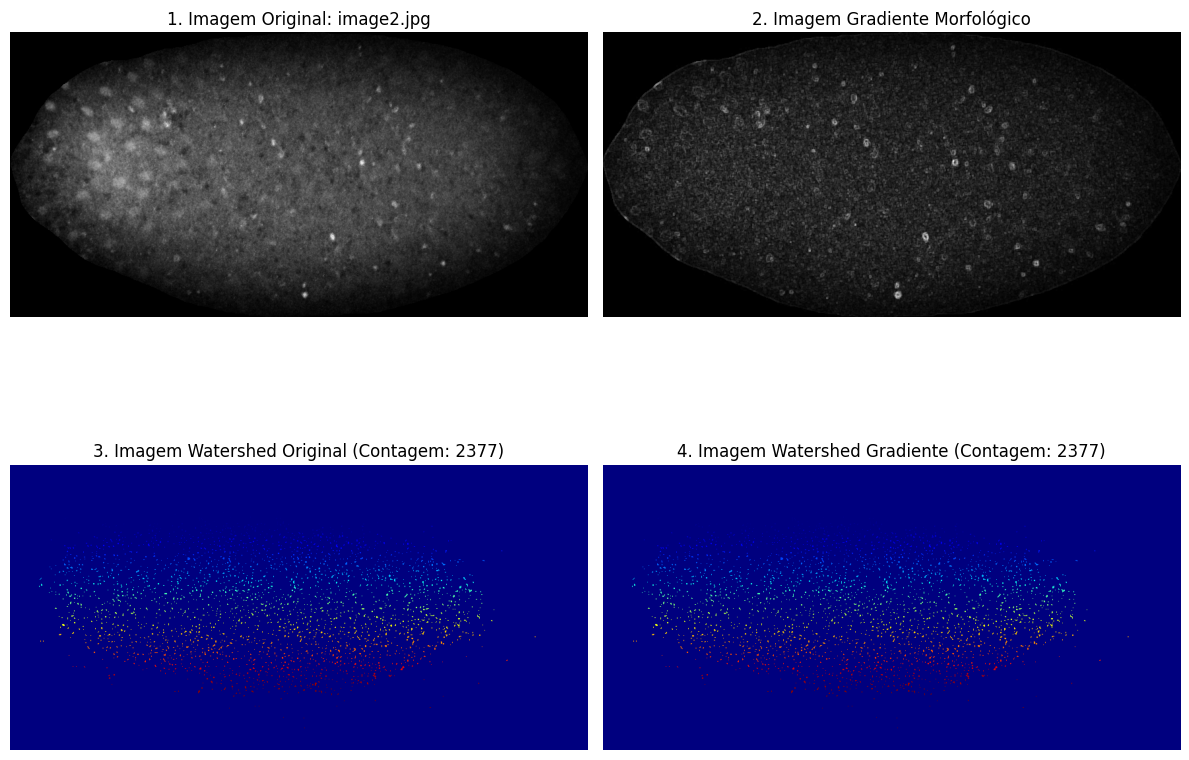

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def watershed_opencv(nome_imagem):
    # 1. Carrega imagem em tons de cinza
    img_gray = cv2.imread(nome_imagem, cv2.IMREAD_GRAYSCALE)
    if img_gray is None:
        print(f"Erro ao carregar '{nome_imagem}'")
        return

    img_bgr = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)
    kernel = np.ones((3, 3), np.uint8)
    
    # 2. Pré-processamento e Gradiente Morfológico
    blur = cv2.GaussianBlur(img_gray, (5, 5), 0)
    gradient = cv2.morphologyEx(img_gray, cv2.MORPH_GRADIENT, kernel)
    grad_bgr = cv2.cvtColor(gradient, cv2.COLOR_GRAY2BGR)
    
    # 3. Geração de Marcadores (Picos de Intensidade = Núcleos das Células)
    local_max = cv2.dilate(blur, np.ones((5, 5), np.uint8))
    peaks = (blur == local_max) & (blur > 30)
    num_labels, markers = cv2.connectedComponents(np.uint8(peaks * 255))
    
    _, thresh_bg = cv2.threshold(blur, 20, 255, cv2.THRESH_BINARY)
    unknown = cv2.bitwise_not(thresh_bg)
    markers = markers + 1
    markers[unknown == 255] = 1 # Fundo
    
    # --- A) WATERSHED OPENCV NA IMAGEM ORIGINAL ---
    m_orig = markers.copy()
    cv2.watershed(img_bgr.copy(), m_orig)
    count_orig = len(np.unique(m_orig[m_orig > 1]))
    
    # --- B) WATERSHED OPENCV NA IMAGEM GRADIENTE ---
    m_grad = markers.copy()
    cv2.watershed(grad_bgr.copy(), m_grad)
    count_grad = len(np.unique(m_grad[m_grad > 1]))
    
    print(f"=== RESULTADOS (OpenCV) PARA: {nome_imagem} ===")
    print(f"Contagem (Imagem Original) : {count_orig} células/objetos")
    print(f"Contagem (Imagem Gradiente): {count_grad} células/objetos\n")
    
    # Imagens com os contornos sobrepostos em vermelho (-1)
    res_orig = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)
    res_orig[m_orig == -1] = [255, 0, 0]
    
    res_grad = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)
    res_grad[m_grad == -1] = [255, 0, 0]
    
    # PLOTAGEM (Mostrando a imagem original, gradiente, a imagem de rótulos do Watershed e o resultado final)
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    axes[0, 0].imshow(img_gray, cmap='gray')
    axes[0, 0].set_title(f"1. Imagem Original: {nome_imagem}")
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(gradient, cmap='gray')
    axes[0, 1].set_title("2. Imagem Gradiente Morfológico")
    axes[0, 1].axis('off')
    
    # Exibe a Imagem de Rótulos do Watershed na Imagem Original (com Colormap 'jet')
    axes[1, 0].imshow(m_orig, cmap='jet')
    axes[1, 0].set_title(f"3. Imagem Watershed Original (Contagem: {count_orig})")
    axes[1, 0].axis('off')
    
    # Exibe a Imagem de Rótulos do Watershed no Gradiente (com Colormap 'jet')
    axes[1, 1].imshow(m_grad, cmap='jet')
    axes[1, 1].set_title(f"4. Imagem Watershed Gradiente (Contagem: {count_grad})")
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

watershed_opencv("image2.jpg")

=== RESULTADOS (OpenCV) PARA: feijao.jpg ===
Contagem (Imagem Original) : 229753 células/objetos
Contagem (Imagem Gradiente): 229753 células/objetos



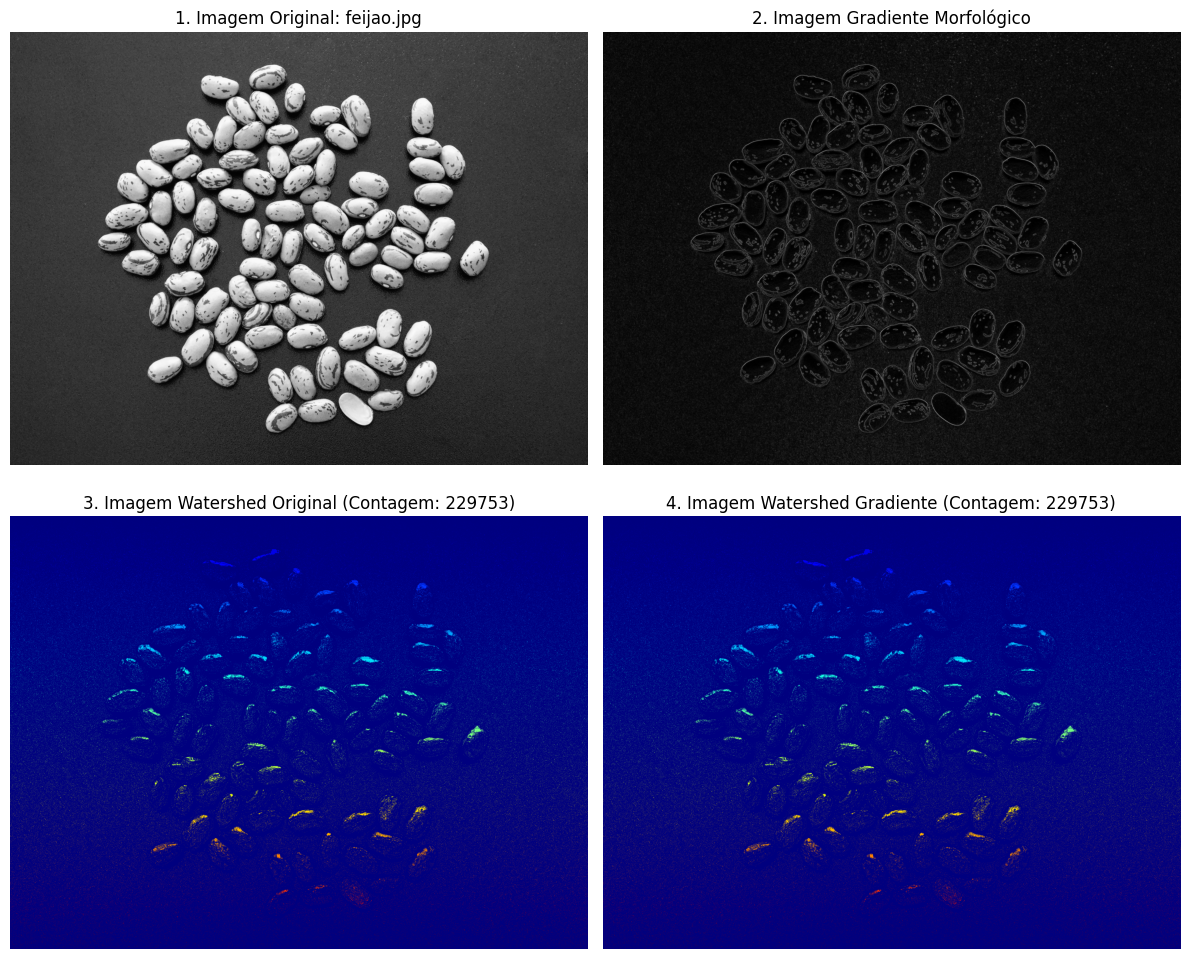

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def watershed_opencv(nome_imagem):
    # 1. Carrega imagem em tons de cinza
    img_gray = cv2.imread(nome_imagem, cv2.IMREAD_GRAYSCALE)
    if img_gray is None:
        print(f"Erro ao carregar '{nome_imagem}'")
        return

    img_bgr = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)
    kernel = np.ones((3, 3), np.uint8)
    
    # 2. Pré-processamento e Gradiente Morfológico
    blur = cv2.GaussianBlur(img_gray, (5, 5), 0)
    gradient = cv2.morphologyEx(img_gray, cv2.MORPH_GRADIENT, kernel)
    grad_bgr = cv2.cvtColor(gradient, cv2.COLOR_GRAY2BGR)
    
    # 3. Geração de Marcadores (Picos de Intensidade = Núcleos das Células)
    local_max = cv2.dilate(blur, np.ones((5, 5), np.uint8))
    peaks = (blur == local_max) & (blur > 30)
    num_labels, markers = cv2.connectedComponents(np.uint8(peaks * 255))
    
    _, thresh_bg = cv2.threshold(blur, 20, 255, cv2.THRESH_BINARY)
    unknown = cv2.bitwise_not(thresh_bg)
    markers = markers + 1
    markers[unknown == 255] = 1 # Fundo
    
    # --- A) WATERSHED OPENCV NA IMAGEM ORIGINAL ---
    m_orig = markers.copy()
    cv2.watershed(img_bgr.copy(), m_orig)
    count_orig = len(np.unique(m_orig[m_orig > 1]))
    
    # --- B) WATERSHED OPENCV NA IMAGEM GRADIENTE ---
    m_grad = markers.copy()
    cv2.watershed(grad_bgr.copy(), m_grad)
    count_grad = len(np.unique(m_grad[m_grad > 1]))
    
    print(f"=== RESULTADOS (OpenCV) PARA: {nome_imagem} ===")
    print(f"Contagem (Imagem Original) : {count_orig} células/objetos")
    print(f"Contagem (Imagem Gradiente): {count_grad} células/objetos\n")
    
    # Imagens com os contornos sobrepostos em vermelho (-1)
    res_orig = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)
    res_orig[m_orig == -1] = [255, 0, 0]
    
    res_grad = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)
    res_grad[m_grad == -1] = [255, 0, 0]
    
    # PLOTAGEM (Mostrando a imagem original, gradiente, a imagem de rótulos do Watershed e o resultado final)
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    axes[0, 0].imshow(img_gray, cmap='gray')
    axes[0, 0].set_title(f"1. Imagem Original: {nome_imagem}")
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(gradient, cmap='gray')
    axes[0, 1].set_title("2. Imagem Gradiente Morfológico")
    axes[0, 1].axis('off')
    
    # Exibe a Imagem de Rótulos do Watershed na Imagem Original (com Colormap 'jet')
    axes[1, 0].imshow(m_orig, cmap='jet')
    axes[1, 0].set_title(f"3. Imagem Watershed Original (Contagem: {count_orig})")
    axes[1, 0].axis('off')
    
    # Exibe a Imagem de Rótulos do Watershed no Gradiente (com Colormap 'jet')
    axes[1, 1].imshow(m_grad, cmap='jet')
    axes[1, 1].set_title(f"4. Imagem Watershed Gradiente (Contagem: {count_grad})")
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

watershed_opencv("feijao.jpg")